# Общая информация

Традиционно набор данных MNIST применяется для старта в освоении машинного обучения и компьютерного зрения.

В качестве альтернативного набора, также, достаточно часто применяется  набор данных **Fashion MNIST**. Подобно MNIST изображения одежды в Fashion MNIST представляют собой двумерные массивы 28х28, где значения в каждой ячейке могут быть в интервале [0, 255]. Метки — массив целых чисел, где каждое значение в интервале [0, 9]. Каждая метка соответствует одному из классов: футболка; шорты; свитер; платье; плащ; сандали; рубашка; кроссовок; сумка; ботинок.

Оба набора данных достаточно малы, поэтому часто используются для проверки корректности работы алгоритма, тестирования и отладки кода. 

Основная цель лабораторной работы – знакомство с набором данных Fashion MNIST. Лабораторная работа основана на материалах, представленных на официальном сайте https://www.tensorflow.org/. Полная версия материалу доступна по ссылке: https://www.tensorflow.org/tutorials/keras/classification?hl=ru

# Простая классификация изображений одежды


Руководство использует [tf.keras](https://www.tensorflow.org/guide/keras), высокоуровневый API для построения и обучения моделей в TensorFlow.



In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow и tf.keras
import tensorflow as tf
from tensorflow import keras

# Вспомогательные библиотеки
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2025-12-01 00:25:50.029276: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-01 00:25:50.081126: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-01 00:25:51.225492: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.20.0


# Загрузка данных

Загрузка датасета [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist). Датасет содержит 70,000 монохромных изображений в 10 категориях. На каждом изображении содержится по одному предмету одежды в низком разрешении (28 на 28 пикселей):

| Метка (Label)  | Класс  | Class |
|:------------- |:---------------| :-------------|
| 0 |Футболки / сверху |  T-shirt/top    |
| 1 |  Брюки       |  Trouser      |
| 2 |    Свитер     |    Pullover    |
| 3 |   Платье      |   Dress     |
| 4 |    Пальто     |   Coat     |
| 5 |    Сандаль     |  Sandal      |
| 6 |   Рубашка      |   Shirt     |
| 7 |    Кроссовок     |    Sneaker    |
| 8 |     Сумка    |    Bag    |
| 9 |       Ботильоны |    Ankle boot    |



In [2]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 134s 5us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 1s 134us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 23s 5us/step


# Формат данных

Загрузка датасета возвращает четыре массива NumPy:

- Массивы train_images и train_labels являются тренировочным сетом — данными, на которых модель будет обучаться.
- Модель тестируется на проверочном сете, а именно массивах test_images и test_labels.

Изображения являются 28х28 массивами NumPy, где значение пикселей варьируется от 0 до 255. Метки - это массив целых чисел от 0 до 9. Они соответствуют классам одежды изображенной на картинках.

Каждому изображению соответствует единственная метка. Так как названия классов не включены в датасет, сохраним их тут для дальнейшего использования при построении изображений:

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Познакомимся с данными

Используя метод **shape** мы видим, что в тренировочном датасете 60,000 изображений, каждое размером 28 x 28 пикселей:

In [4]:
train_images.shape

(60000, 28, 28)

Соответственно, в тренировочном сете 60,000 меток:

In [5]:
len(train_labels)

60000

Каждая метка это целое число от 0 до 9:

In [6]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

Проверочный сет содержит 10,000 изображений, каждое - также 28 на 28 пикселей:

In [7]:
test_images.shape

(10000, 28, 28)

И в проверочном сете - ровно 10,000 меток:

In [8]:
len(test_labels)

10000

# Предобработка данных

Данные должны быть предобработаны перед обучением нейросети. Если вы посмотрите на первое изображение в тренировочном сете вы увидите, что значения пикселей находятся в диапазоне от 0 до 255:

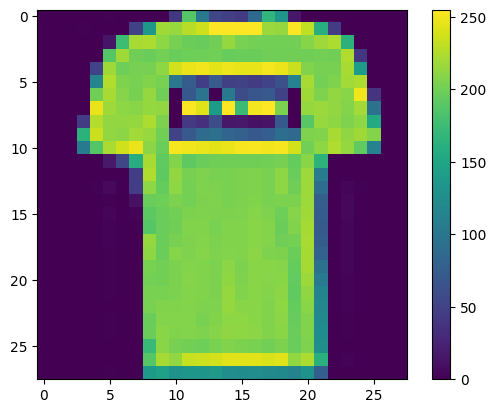

In [9]:
plt.figure()
plt.imshow(train_images[1])
plt.colorbar()
plt.grid(False)
plt.show()

Мы масштабируем эти значения к диапазону от 0 до 1 перед тем как применять данные для обучения нейросети. Для этого нужно разделить значения на 255. 


Важно, чтобы тренировочный сет и проверочный сет были предобработаны одинаково:

In [10]:
train_images = train_images / 255.0

test_images = test_images / 255.0

Чтобы убедиться, что данные в правильном формате и мы готовы построить и обучить нейросеть, выведем на экран первые 25 изображений из тренировочного сета и отобразим под ними наименования их классов:

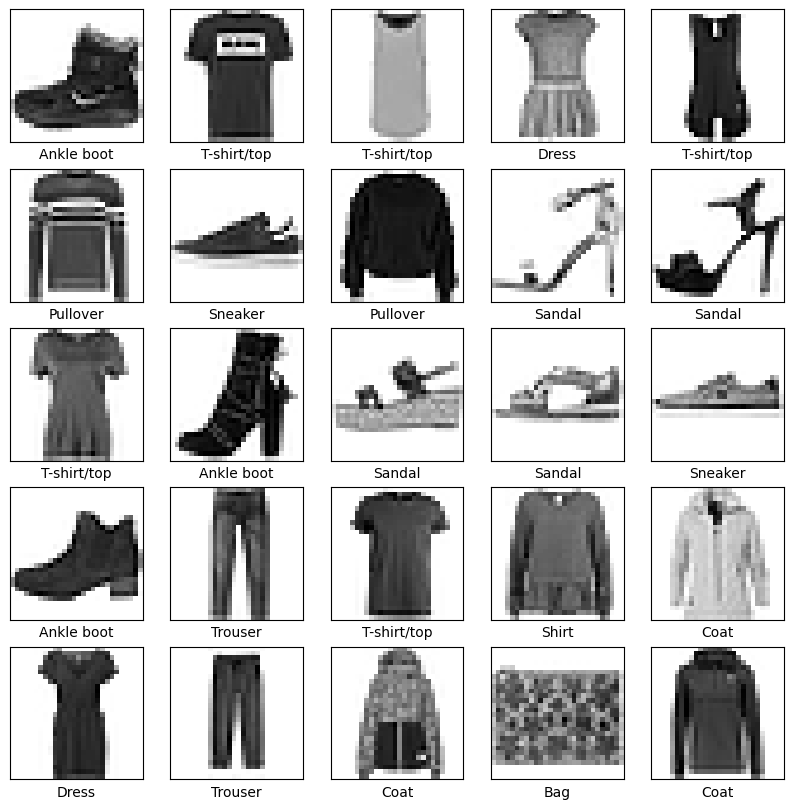

In [11]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

# Построение модели нейронной сети

### Настройте слои

Базовым строительным блоком нейронной сети является слой. 


Слои извлекают образы из данных, которые в них подаются. 

Большая часть глубокого обучения состоит из соединения в последовательность простых слоев. Большинство слоев, таких как tf.keras.layers.Dense, имеют параметры, которые настраиваются во время обучения.

In [12]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/home/alexcawl/VsCodeProjects/SUSU.PE/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1764530913.225414   61782 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1764530913.231873   61782 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Первый слой этой сети - tf.keras.layers.Flatten, преобразует формат изображения из двумерного массива (28 на 28 пикселей) в одномерный (размерностью 28 * 28 = 784 пикселя). Слой извлекает строки пикселей из изображения и выстраивает их в один ряд. Этот слой не имеет параметров для обучения; он только переформатирует данные.

После разложения пикселей, нейросеть содержит два слоя tf.keras.layers.Dense. Это полносвязные нейронные слои. Первый Dense слой состоит из 128 узлов (или нейронов). Второй (и последний) 10-узловой softmax слой возвращает массив из 10 вероятностных оценок дающих в сумме 1. Каждый узел содержит оценку указывающую вероятность принадлежности изображения к одному из 10 классов.

# Скомпилируйте модель
Прежде чем модель будет готова для обучения, нам нужно указать еще несколько параметров. Они добавляются на шаге compile модели:

*   Функция потерь (Loss function) — измеряет точность модели во время обучения. Мы хотим минимизировать эту функцию чтоб "направить" модель в верном направлении.
*   Оптимизатор (Optimizer) — показывает каким образом обновляется модель на основе входных данных и функции потерь.
* Метрики (Metrics) — используются для мониторинга тренировки и тестирования модели. Наш пример использует метрику accuracy равную доле правильно классифицированных изображений.





In [13]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Обучите модель

Обучение модели нейронной сети требует выполнения следующих шагов::

1. Подайте тренировочный данные в модель. В этом примере тренировочные данные это массивы train_images и train_labels.
2. Модель учится ассоциировать изображения с правильными классами.
3. Мы просим модель сделать прогнозы для проверочных данных, в этом примере массив test_images. Мы проверяем, соответствуют ли предсказанные классы меткам из массива test_labels.
Для начала обучения, вызовите метод model.fit, который называется так, поскольку "тренирует (fits)" модель на тренировочных данных:

In [14]:
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8235 - loss: 0.5026
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8644 - loss: 0.3747
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8771 - loss: 0.3364
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8836 - loss: 0.3146
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8907 - loss: 0.2949
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8971 - loss: 0.2794
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9011 - loss: 0.2673
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9041 - loss: 0.2580
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9071 - loss: 0.2478
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9096 - loss: 0.2403


В процессе обучения модели отображаются метрики потери (loss) и точности (accuracy). Эта модель достигает на тренировочных данных точности равной приблизительно 0.88 (88%).


# Оценка точности
Далее, сравните какую точность модель покажет на проверчном датасете:

In [15]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nТочность на проверочных данных:', test_acc)

313/313 - 0s - 903us/step - accuracy: 0.8839 - loss: 0.3337

Точность на проверочных данных: 0.883899986743927


Полученная на проверочном сете точность оказалась немного ниже, чем на тренировочном. Этот разрыв между точностью на тренировке и тесте является примером переобучения (overfitting) . Переобучение возникает, когда модель машинного обучения показывает на новых данных худший результат, чем на тех, на которых она обучалась.

## Сделайте предсказания
Теперь, когда модель обучена, мы можем использовать ее чтобы сделать предсказания по поводу нескольких изображений:

In [16]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step


Здесь полученная модель предсказала класс одежды для каждого изображения в проверочном датасете. Давайте посмотрим на первое предсказание:

In [17]:
predictions[0]

array([5.9797844e-07, 1.3000900e-10, 1.4530694e-09, 5.3559349e-13,
       1.2405605e-08, 1.2179696e-02, 4.3459753e-08, 3.4383867e-02,
       1.6170683e-05, 9.5341963e-01], dtype=float32)

Прогноз представляет из себя массив из 10 чисел. Они описывают "уверенность" (confidence) модели в том, насколько изображение соответствует каждому из 10 разных видов одежды. Мы можем посмотреть какой метке соответствует максимальное значение:

In [18]:
np.argmax(predictions[0])

np.int64(9)

Модель полагает, что на первой картинке изображен ботинок (ankle boot), или class_names[9]. Проверка показывает, что классификация верна:

In [19]:
test_labels[0]

np.uint8(9)

Мы можем построить график, чтобы взглянуть на полный набор из 10 предсказаний классов.

In [20]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array[i], true_label[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

Давайте посмотрим на нулевое изображение, предсказание и массив предсказаний.

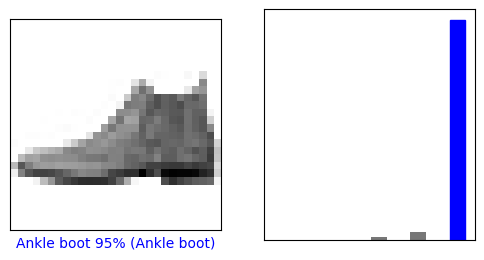

In [21]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions,  test_labels)
plt.show()

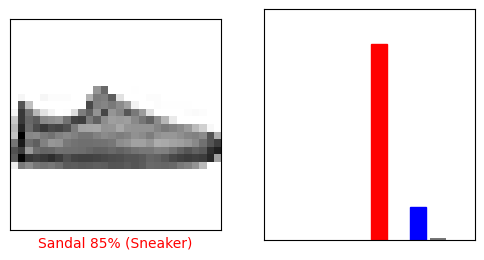

In [22]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions,  test_labels)
plt.show()

Давайте посмотрим несколько изображений с их прогнозами. Цвет верных предсказаний синий, а неверных - красный. Число это процент уверенности (от 100) для предсказанной метки. Отметим, что модель может ошибаться даже если она очень уверена.

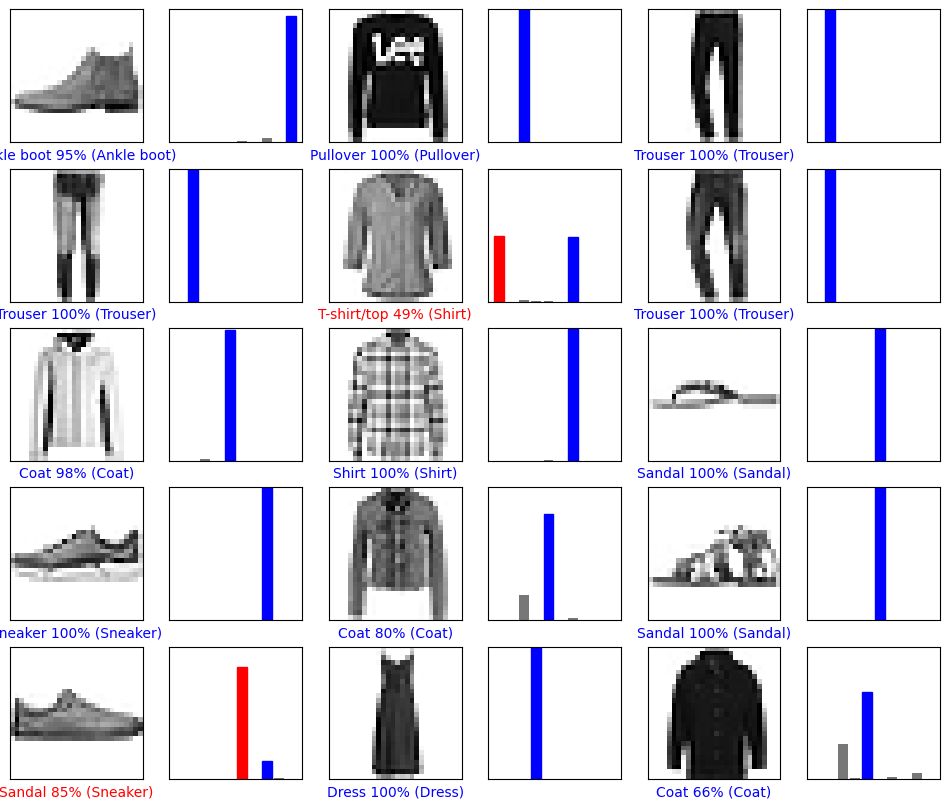

In [23]:
# Отображаем первые X тестовых изображений, их предсказанную и настоящую метки.
# Корректные предсказания окрашиваем в синий цвет, ошибочные в красный.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions, test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions, test_labels)
plt.show()

Наконец, используем обученную модель для предсказания класса на одном изображении.

In [24]:
# Берем одну картинку из проверочного сета.
img = test_images[0]

print(img.shape)

(28, 28)


Модели tf.keras оптимизированы для предсказаний на пакетах (batch) данных, или на множестве примеров сразу. Таким образом, даже если мы используем всего 1 картинку, нам все равно необходимо добавить ее в список:

In [25]:
# Добавляем изображение в пакет данных, состоящий только из одного элемента.
img = (np.expand_dims(img,0))

print(img.shape)

(1, 28, 28)


Сейчас предскажем правильную метку для изображения:

In [26]:
predictions_single = model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[5.9797901e-07 1.3000950e-10 1.4530696e-09 5.3559251e-13 1.2405582e-08
  1.2179674e-02 4.3459671e-08 3.4383826e-02 1.6170668e-05 9.5341969e-01]]


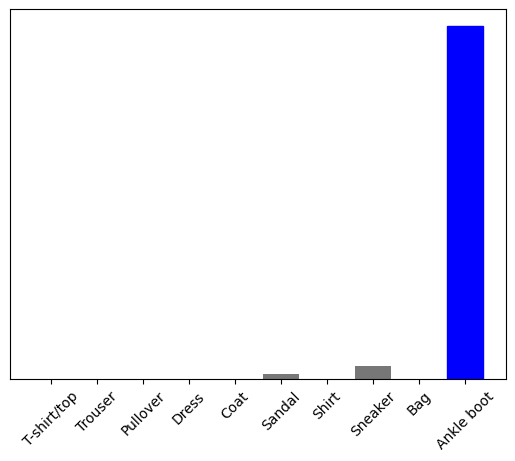

In [27]:
plot_value_array(0, predictions_single, test_labels)
_ = plt.xticks(range(10), class_names, rotation=45)

In [28]:
np.argmax(predictions_single[0])

np.int64(9)

И, как и ранее, модель предсказывает класс 9.

# Задание
Сфотографируйте элемент своей одежды (например, ботинок), добавьте код для предобработки изображений, попробуйте определить класс предмета одежды с помощью обученной нейронной сети.

In [144]:
from PIL import Image
import numpy as np

def process_image(path, inverse=False):
    # Загрузка изображения
    img = Image.open(path).convert("L")  # ч/б, поэтому convert("L")
    img = img.resize((28, 28))
    img_array = np.array(img)
    # Нормализация значений цвета в диапазон [0, 1]
    img_array = img_array.astype("float32") / 255.0
    if inverse:
        img_array = 1.0 - img_array
    img_output = img_array.reshape(1, 28, 28)
    return img_array, img_output

In [145]:
tshirt_img, tshirt = process_image('../Практическая работа 6/t-shirt_preprocessed.jpg')
sneaker_img, sneaker = process_image('../Практическая работа 6/sneaker_preprocessed.jpg')

In [146]:
pred = model.predict(tshirt)
pred_class = np.argmax(pred)
print(f"Предсказанный класс: {class_names[pred_class]}, метка класса: {pred_class}")
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Предсказанный класс: T-shirt/top, метка класса: 0


array([[5.45464456e-01, 6.44764048e-04, 1.44621935e-02, 5.10764681e-03,
        2.13327512e-04, 2.48651686e-05, 4.30994928e-01, 1.87714519e-07,
        2.98912497e-03, 9.84819926e-05]], dtype=float32)

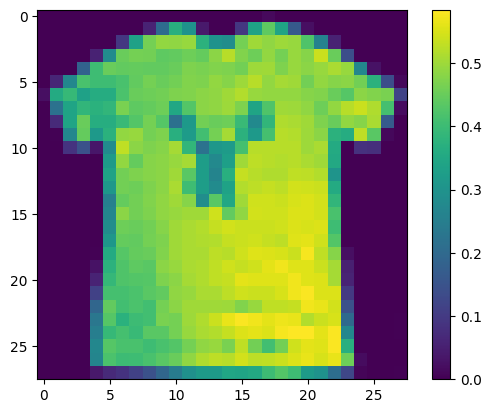

In [147]:
plt.figure()
plt.imshow(tshirt_img)
plt.colorbar()
plt.grid(False)
plt.show()

In [148]:
pred = model.predict(sneaker)
pred_class = np.argmax(pred)
print(f"Предсказанный класс: {class_names[pred_class]}, метка класса: {pred_class}")
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Предсказанный класс: Sneaker, метка класса: 7


array([[1.8861048e-05, 6.3919275e-10, 5.1357432e-07, 1.7748364e-09,
        5.7252801e-06, 2.7296323e-01, 4.7009271e-07, 7.2523814e-01,
        9.2190530e-05, 1.6808369e-03]], dtype=float32)

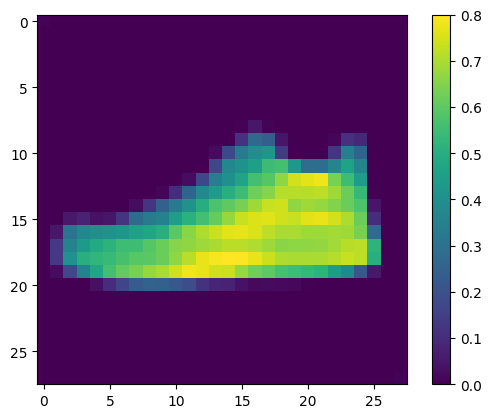

In [149]:
plt.figure()
plt.imshow(sneaker_img)
plt.colorbar()
plt.grid(False)
plt.show()